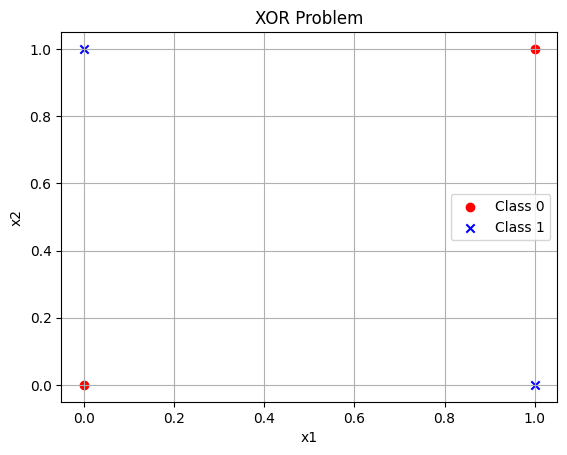

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# XOR data
X = np.array([
    [0, 0],
    [1, 1],
    [0, 1],
    [1, 0]
])
y = np.array([0, 0, 1, 1])

# Plot
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i,0], X[i,1], color='red', marker='o', label='Class 0' if i==0 else "")
    else:
        plt.scatter(X[i,0], X[i,1], color='blue', marker='x', label='Class 1' if i==2 else "")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Problem")
plt.legend()
plt.grid()
plt.show()

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y)

pred = model.predict(X)

print("Predictions:", pred)
print("Accuracy:", model.score(X, y))

Predictions: [0 0 0 0]
Accuracy: 0.5


In [3]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', gamma='auto')
svm_model.fit(X, y)

pred_svm = svm_model.predict(X)

print("SVM Predictions:", pred_svm)
print("Accuracy:", svm_model.score(X, y))

SVM Predictions: [0 0 1 1]
Accuracy: 1.0


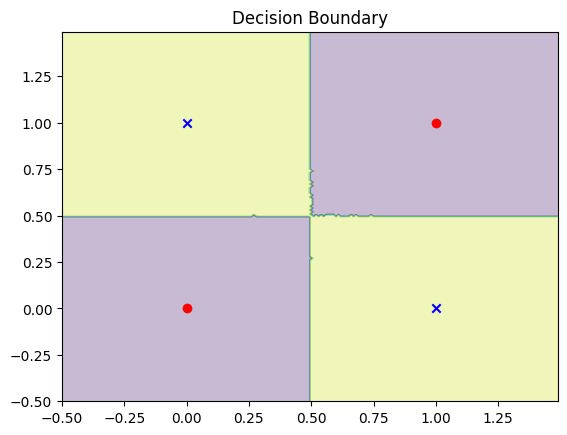

In [4]:
def plot_decision_boundary(model, X, y):
    h = 0.01
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i,0], X[i,1], color='red', marker='o')
        else:
            plt.scatter(X[i,0], X[i,1], color='blue', marker='x')
    
    plt.title("Decision Boundary")
    plt.show()

# Plot SVM boundary
plot_decision_boundary(svm_model, X, y)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
tf.random.set_seed(42)

# Build a small neural network to learn XOR
# A hidden layer is required because XOR is not linearly separable.
tf_model = Sequential([
    Dense(8, activation="tanh", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

tf_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

tf_model.fit(X, y, epochs=500, verbose=0)

# Evaluate on XOR points
probs = tf_model.predict(X, verbose=0).ravel()
pred_tf = (probs >= 0.5).astype(int)
acc_tf = accuracy_score(y, pred_tf)

print("TensorFlow Neural Network")
print("Probabilities:", np.round(probs, 4))
print("Predictions:", pred_tf)
print(f"Accuracy: {acc_tf:.2f}")
print(classification_report(y, pred_tf, zero_division=0))

# Plot TensorFlow decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz_prob = tf_model.predict(grid, verbose=0).reshape(xx.shape)
zz = (zz_prob >= 0.5).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")

colors = ["tab:blue" if cls == 0 else "tab:orange" for cls in y]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=120, edgecolor="black")
for i, (x1, x2) in enumerate(X):
    ax.text(x1 + 0.02, x2 + 0.02, f"P{i}", fontsize=9)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title(f"TensorFlow XOR Decision Boundary (Acc={acc_tf:.2f})")
ax.grid(alpha=0.25)
plt.show()